In [28]:
import lettuce as lt
import numpy as np
import matplotlib.pyplot as plt

In [29]:
device = 'cuda'
resolution = 300
reynolds_number = 30000
mach_number = 0.1

In [30]:
lattice = lt.Lattice(lt.D2Q9, device=device,)
flow = lt.TaylorGreenVortex2D(resolution=resolution, reynolds_number=reynolds_number, mach_number=mach_number, lattice=lattice)
collision = lt.BGKCollision(lattice, tau=flow.units.relaxation_parameter_lu)
streaming = lt.StandardStreaming(lattice)
simulation = lt.Simulation(flow=flow, lattice=lattice,  collision=collision, streaming=streaming)

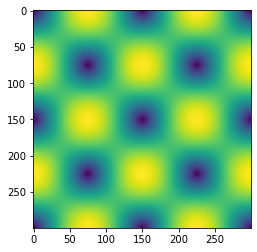

In [31]:
u = lattice.u(simulation.f).cpu().numpy()
u = np.sqrt(u[0]**2+u[1]**2)
plt.imshow(u)
plt.show()

In [32]:
simulation.reporters.append(lt.EnergyReporter(lattice, flow, interval=50, starting_iteration=0))

steps     Kinetic energy


In [33]:
mlups = simulation.step(num_steps=100)
#energy = simulation.reporters[0]

50 9.868666648864746
100 9.867758750915527


In [34]:
print(simulation.reporters[0].out)